# EDA_unito

Notebook unico di EDA per il progetto di Data Management.

Uso nomi di variabili semplici:

- `df_dino` per i dinosauri;
- `df_plants` per le piante;
- `df_fossili` per il dataset unito;
- `df_fossili_clean` per il dataset unito dopo pulizia e feature engineering.


## Struttura

1. Import librerie
2. Load dataset
3. EDA dinosauri
4. EDA piante
5. EDA confronto dinosauri-piante
6. Feature engineering
7. Studio riempimento tassonomia
8. Conclusioni

Le sezioni EDA dinosauri e EDA piante sono uguali come ordine.


## 1. Import librerie


### 1.1 Setup librerie


#### 1.1.1 Import librerie


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
rosso = 'firebrick'
verde = 'forestgreen' 

## 2. Load dataset


### 2.1 Caricamento dataset


#### 2.1.1 Caricamento dataset


In [2]:
df_dino = pd.read_csv('dinos.csv')
df_plants = pd.read_csv('plants.csv')


#### 2.1.2 Dimensioni dei dataset


In [3]:
print('Dinosauri:', df_dino.shape)
print('Piante:', df_plants.shape)


Dinosauri: (37790, 38)
Piante: (57394, 38)


#### 2.1.3 Anteprima dinosauri


In [4]:
df_dino.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


#### 2.1.4 Anteprima piante


In [5]:
df_plants.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,31284,occ,NaN,NaN,2260,Algae indet.,class,NaN,NaN,Algae,...,This is a collection based on a composite of t...,121.0,Alikper,NaN,NaN,NO_PHYLUM_SPECIFIED,Algae,NaN,NaN,NaN
1,45807,occ,NaN,NaN,3640,? Caryophyllidae indet.,subclass,NaN,NaN,Caryophyllidae,...,Pitt Island,39.0,Kahuitara Tuff,NaN,NaN,Angiospermae,Dicotyledoneae,NaN,NaN,NaN
2,77082,occ,NaN,NaN,1573,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77169,occ,NaN,NaN,1567,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,82793,occ,NaN,NaN,1555,Diplopora versipora,genus,NaN,species not entered,Diplopora,...,coastal cliff between Black Head and Shortlake,126.0,Trigonia clavellata,NaN,NaN,Chlorophyta,Chlorophyceae,Dasycladales,Diploporaceae,Diplopora


## 3. EDA dinosauri


### 3.1 Anteprima e struttura


#### 3.1.1 Prime righe dinosauri


In [6]:
df_dino.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,at Dummer's Copse between Allington Lane and Q...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,"at Dummer's Copse, between Allington Lane and ...",37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,"Chaoyang area of Liaoning Province, NE China",2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,Sihetun area near Beipiao city,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx


#### 3.1.2 Info colonne dinosauri


In [7]:
df_dino.info()


<class 'pandas.DataFrame'>
RangeIndex: 37790 entries, 0 to 37789
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     37790 non-null  int64  
 1   record_type       37790 non-null  str    
 2   reid_no           4154 non-null   float64
 3   flags             3417 non-null   str    
 4   collection_no     37790 non-null  int64  
 5   identified_name   37790 non-null  str    
 6   identified_rank   37790 non-null  str    
 7   identified_no     12703 non-null  float64
 8   difference        3889 non-null   str    
 9   accepted_name     37790 non-null  str    
 10  accepted_attr     37748 non-null  str    
 11  accepted_rank     37790 non-null  str    
 12  accepted_no       37790 non-null  int64  
 13  early_interval    37790 non-null  str    
 14  late_interval     8675 non-null   str    
 15  max_ma            37790 non-null  float64
 16  min_ma            37790 non-null  float64
 17  refe

### 3.2 Valori mancanti


#### 3.2.1 Conteggio valori nulli


In [8]:
df_dino.isnull().sum()


occurrence_no           0
record_type             0
reid_no             33636
flags               34373
collection_no           0
identified_name         0
identified_rank         0
identified_no       25087
difference          33901
accepted_name           0
accepted_attr          42
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       29115
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                     17
state                6320
county              19061
latlng_basis         1611
latlng_precision        0
altitude_value      29120
altitude_unit       29211
geogscale            6627
geogcomments         7883
cx_int_no              62
formation           14347
geological_group    27438
member              30582
phylum                  0
class                   0
order                7379
family               8723
genus               14232
dtype: int64

#### 3.2.2 Percentuale valori nulli


In [9]:
(df_dino.isnull().sum() / len(df_dino) * 100).round(2)


occurrence_no        0.00
record_type          0.00
reid_no             89.01
flags               90.96
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       66.39
difference          89.71
accepted_name        0.00
accepted_attr        0.11
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       77.04
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.04
state               16.72
county              50.44
latlng_basis         4.26
latlng_precision     0.00
altitude_value      77.06
altitude_unit       77.30
geogscale           17.54
geogcomments        20.86
cx_int_no            0.16
formation           37.97
geological_group    72.61
member              80.93
phylum               0.00
class                0.00
order               19.53
family              23.08
genus               37.66
dtype: float

#### 3.2.3 Colonne con piu valori nulli


In [10]:
nulli_dino = (df_dino.isnull().sum() / len(df_dino) * 100).sort_values(ascending=False).head(15)
nulli_dino


flags               90.957925
difference          89.708918
reid_no             89.007674
member              80.926171
altitude_unit       77.298227
altitude_value      77.057423
late_interval       77.044192
geological_group    72.606510
identified_no       66.385287
county              50.439270
formation           37.965070
genus               37.660757
family              23.082826
geogcomments        20.860016
order               19.526330
dtype: float64

#### 3.2.4 Grafico valori mancanti


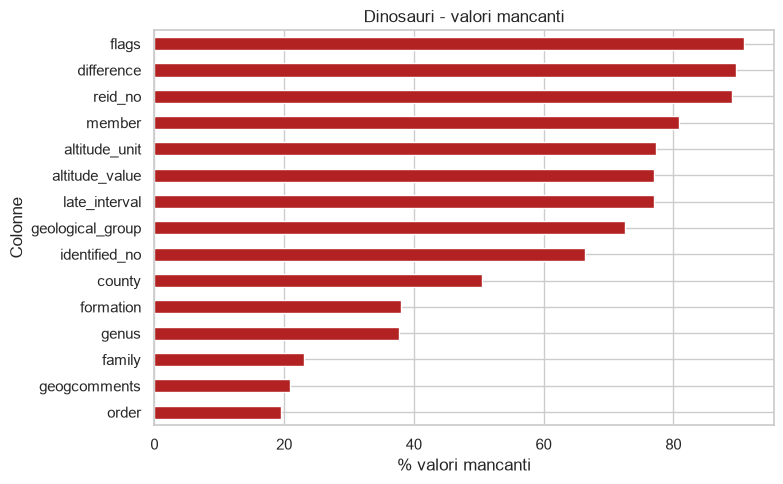

In [11]:
nulli_dino.sort_values().plot(kind='barh', color=rosso, figsize=(8, 5))
plt.title('Dinosauri - valori mancanti')
plt.xlabel('% valori mancanti')
plt.ylabel('Colonne')
plt.tight_layout()
plt.show()


### 3.3 Duplicati


#### 3.3.1 Controllo duplicati


In [12]:
df_dino.duplicated().sum()


np.int64(0)

### 3.4 Conteggi per categoria


#### 3.4.1 Conteggio classi


In [13]:
df_dino['class'].value_counts(dropna=False).head(15)


class
Aves            15173
Reptilia        11164
Ornithischia     7058
Saurischia       4395
Name: count, dtype: int64

#### 3.4.2 Conteggio ordini


In [14]:
df_dino['order'].value_counts(dropna=False).head(15)


order
NO_ORDER_SPECIFIED    14825
NaN                    7379
Passeriformes          2352
Charadriiformes        1949
Anseriformes           1821
Gruiformes             1040
Procellariiformes       959
Galliformes             934
Accipitriformes         782
Columbiformes           744
Suliformes              741
Strigiformes            604
Pelecaniformes          424
Sphenisciformes         317
Falconiformes           299
Name: count, dtype: int64

#### 3.4.3 Conteggio famiglie


In [15]:
df_dino['family'].value_counts(dropna=False).head(15)


family
NaN                    8723
NO_FAMILY_SPECIFIED    3043
Anatidae               1731
Hadrosauridae          1623
Dromaeosauridae        1015
Grallatoridae           835
Accipitridae            760
Procellariidae          756
Ceratopsidae            747
Columbidae              744
Rallidae                727
Phasianidae             662
Alcidae                 545
Tyrannosauridae         510
Scolopacidae            507
Name: count, dtype: int64

#### 3.4.4 Conteggio generi


In [16]:
df_dino['genus'].value_counts(dropna=False).head(15)


genus
NaN                14232
Grallator            431
Anas                 336
Eubrontes            304
Phalacrocorax        278
Corvus               270
Puffinus             244
Richardoestesia      238
Falco                198
Megaloolithus        183
Turdus               177
Pterodroma           174
Buteo                170
Triceratops          166
Anomoepus            158
Name: count, dtype: int64

#### 3.4.5 Conteggio paesi


In [17]:
df_dino['cc'].value_counts(dropna=False).head(15)


cc
US    11377
CA     2225
ES     2224
CN     1975
NZ     1268
AR     1215
UK     1184
FR     1037
MN      980
AU      830
IT      681
MX      584
BR      582
PT      533
MG      419
Name: count, dtype: int64

#### 3.4.6 Conteggio intervalli geologici


In [18]:
df_dino['early_interval'].value_counts(dropna=False).head(15)


early_interval
Holocene               5409
Late Pleistocene       4772
Late Campanian         2619
Late Maastrichtian     1511
Maastrichtian          1387
Kimmeridgian           1109
Middle Campanian        955
Aptian                  955
Hettangian              800
Early Maastrichtian     696
Campanian               637
Lancian                 589
Late Kimmeridgian       558
Middle Pleistocene      541
Norian                  522
Name: count, dtype: int64

### 3.5 Statistiche descrittive


#### 3.5.1 Statistiche descrittive


In [19]:
df_dino.describe()


,occurrence_no,reid_no,collection_no,identified_no,accepted_no,max_ma,min_ma,reference_no,lng,lat,altitude_value,cx_int_no
count,3.779000e+04,4154.000000,37790.000000,12703.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,37790.000000,8670.000000,37728.000000
mean,1.111161e+06,30509.549350,122537.062159,210102.997953,136205.014051,71.008821,64.523279,49143.774358,-19.988668,24.989404,991.356055,189.010549
std,4.505221e+05,8840.766784,73859.233773,136267.822972,132610.253551,65.819122,61.616788,26523.281573,92.791387,29.819606,1148.334106,294.044695
min,4.152400e+04,10063.000000,3256.000000,36610.000000,36616.000000,0.011700,0.000000,149.000000,-179.154999,-84.333336,-917.000000,1.000000
25%,6.322072e+05,22477.250000,53074.000000,91970.000000,38831.000000,0.129000,0.011700,24059.000000,-106.646927,18.330000,192.000000,37.000000
50%,1.273561e+06,32464.500000,109831.500000,143772.000000,64125.000000,72.200000,66.000000,55247.500000,-17.858500,37.404999,689.000000,112.000000
75%,1.468913e+06,38361.750000,194642.000000,368309.000000,186242.000000,121.400000,100.500000,70791.000000,35.373600,43.572224,1334.000000,119.000000
max,2.066136e+06,43269.000000,279154.000000,515615.000000,520798.000000,251.902000,248.100000,327912.000000,178.677002,89.039169,10421.000000,1203.000000


#### 3.5.2 Statistiche colonne numeriche


In [20]:
df_dino[['max_ma', 'min_ma', 'lng', 'lat']].describe()


,max_ma,min_ma,lng,lat
count,37790.000000,37790.000000,37790.000000,37790.000000
mean,71.008821,64.523279,-19.988668,24.989404
std,65.819122,61.616788,92.791387,29.819606
min,0.011700,0.000000,-179.154999,-84.333336
25%,0.129000,0.011700,-106.646927,18.330000
50%,72.200000,66.000000,-17.858500,37.404999
75%,121.400000,100.500000,35.373600,43.572224
max,251.902000,248.100000,178.677002,89.039169


### 3.6 Visualizzazioni


#### 3.6.1 Grafico classi frequenti


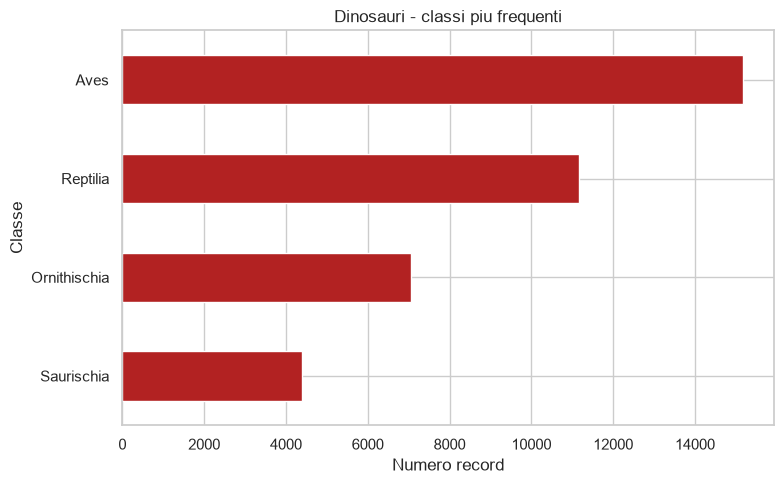

In [21]:
df_dino['class'].value_counts().head(10).sort_values().plot(kind='barh', color=rosso, figsize=(8, 5))
plt.title('Dinosauri - classi piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()


#### 3.6.2 Grafico intervalli frequenti


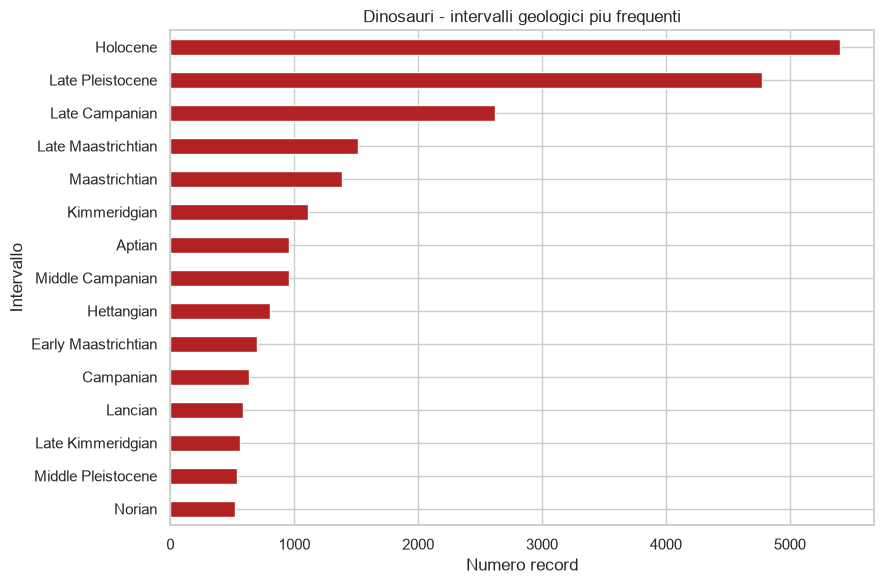

In [22]:
df_dino['early_interval'].value_counts().head(15).sort_values().plot(kind='barh', color=rosso, figsize=(9, 6))
plt.title('Dinosauri - intervalli geologici piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Intervallo')
plt.tight_layout()
plt.show()


#### 3.6.3 Istogramma eta


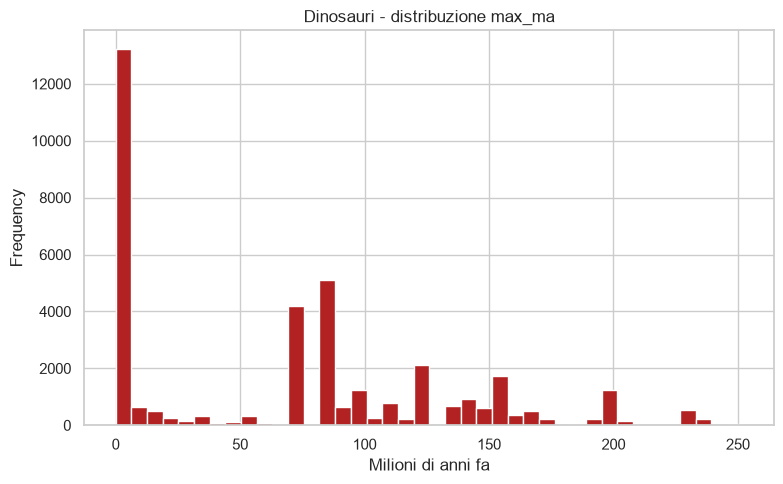

In [23]:
df_dino['max_ma'].dropna().plot(kind='hist', bins=40, color=rosso, figsize=(8, 5))
plt.title('Dinosauri - distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.tight_layout()
plt.show()


#### 3.6.4 Boxplot eta


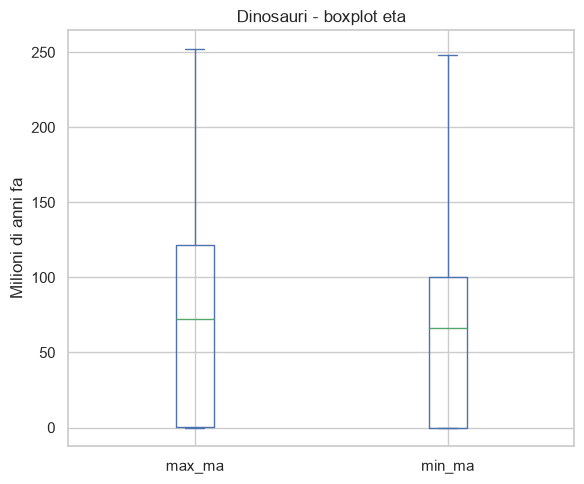

In [24]:
df_dino[['max_ma', 'min_ma']].plot(kind='box', figsize=(6, 5))
plt.title('Dinosauri - boxplot eta')
plt.ylabel('Milioni di anni fa')
plt.tight_layout()
plt.show()


### 3.7 Grafici Seaborn

Grafici un po' piu leggibili per riassumere le informazioni principali dei dinosauri.


#### 3.7.1 Grafico seaborn classi


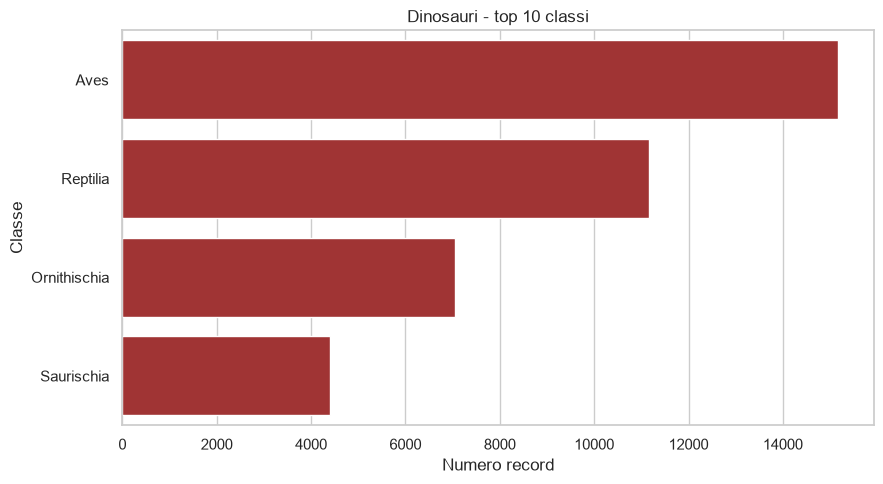

In [25]:
top_classi_dino = df_dino['class'].value_counts().head(10).reset_index()
top_classi_dino.columns = ['class', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_classi_dino, x='conteggio', y='class', color=rosso)
plt.title('Dinosauri - top 10 classi')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()


#### 3.7.2 Grafico seaborn paesi


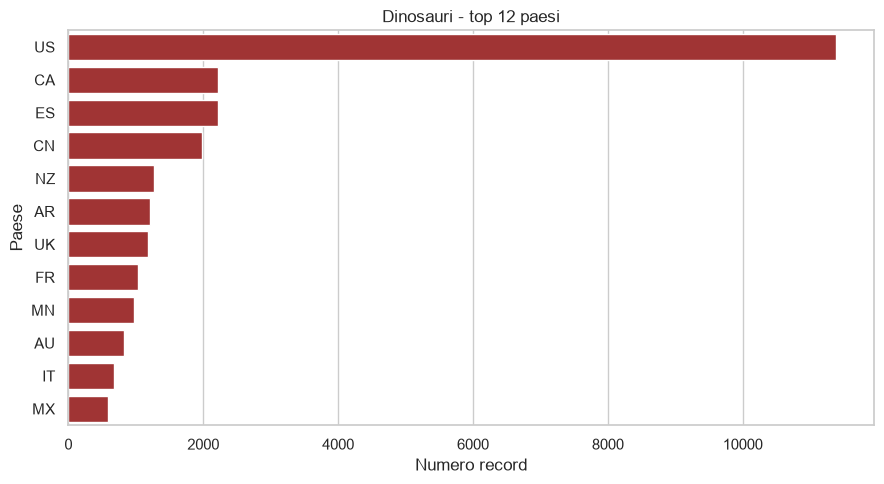

In [26]:
top_paesi_dino = df_dino['cc'].value_counts().head(12).reset_index()
top_paesi_dino.columns = ['cc', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_paesi_dino, x='conteggio', y='cc', color=rosso)
plt.title('Dinosauri - top 12 paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()


#### 3.7.3 Distribuzione temporale seaborn


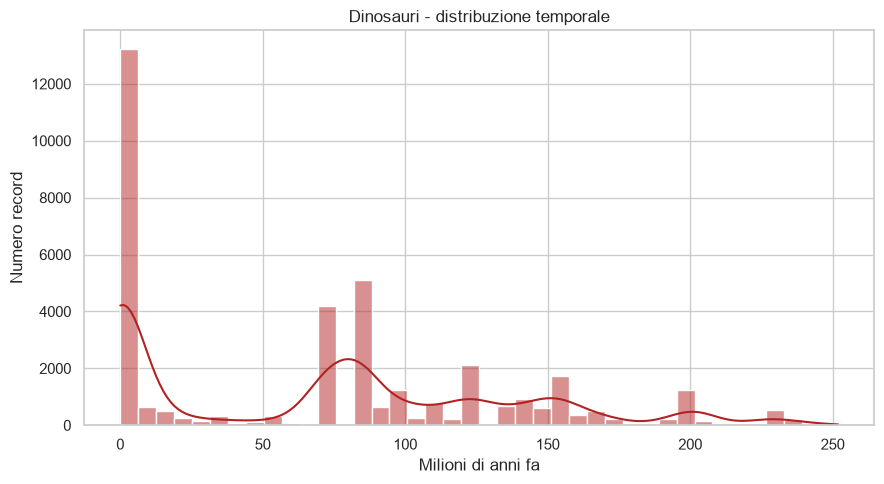

In [27]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_dino, x='max_ma', bins=40, kde=True, color=rosso)
plt.title('Dinosauri - distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()


#### 3.7.4 Boxplot eta per classi


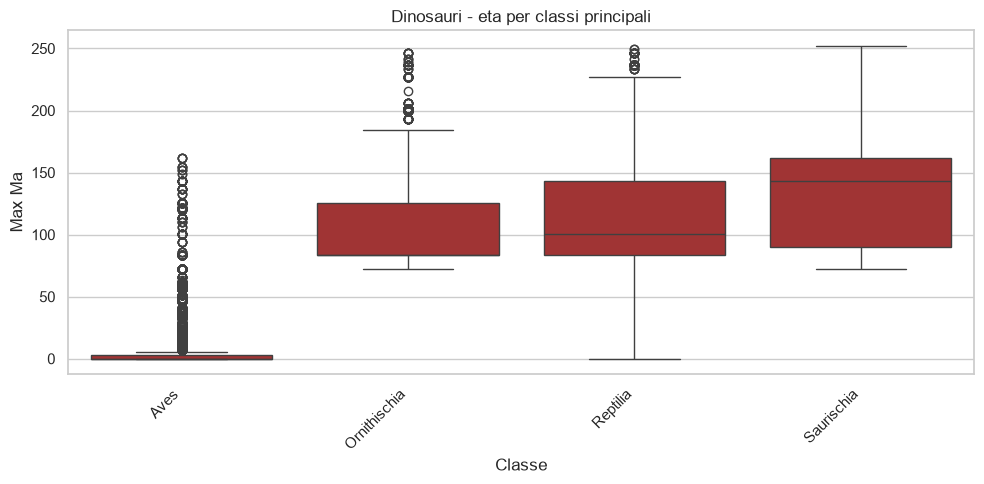

In [28]:
classi_top_dino = df_dino['class'].value_counts().head(5).index
df_dino_classi_top = df_dino[df_dino['class'].isin(classi_top_dino)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_dino_classi_top, x='class', y='max_ma', color=rosso)
plt.title('Dinosauri - eta per classi principali')
plt.xlabel('Classe')
plt.ylabel('Max Ma')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 3.7.5 Coordinate geografiche


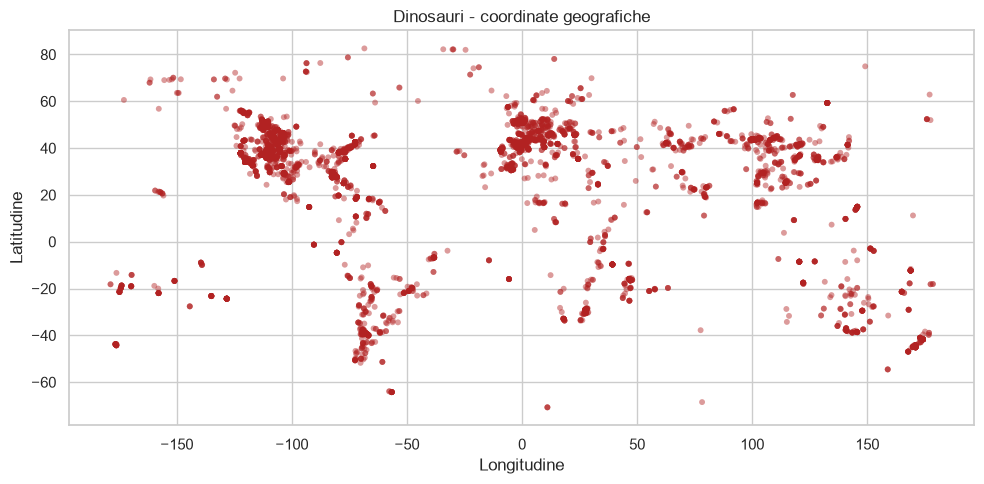

In [29]:
df_dino_geo_sns = df_dino.dropna(subset=['lng', 'lat'])
df_dino_geo_sns = df_dino_geo_sns[df_dino_geo_sns['lat'].between(-90, 90)]
df_dino_geo_sns = df_dino_geo_sns[df_dino_geo_sns['lng'].between(-180, 180)]

if len(df_dino_geo_sns) > 5000:
    df_dino_geo_sns = df_dino_geo_sns.sample(5000, random_state=1)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_dino_geo_sns, x='lng', y='lat', color=rosso, alpha=0.45, s=18, edgecolor='none')
plt.title('Dinosauri - coordinate geografiche')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.tight_layout()
plt.show()


## 4. EDA piante


### 4.1 Anteprima e struttura


#### 4.1.1 Prime righe piante


In [30]:
df_plants.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,geogcomments,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus
0,31284,occ,NaN,NaN,2260,Algae indet.,class,NaN,NaN,Algae,...,This is a collection based on a composite of t...,121.0,Alikper,NaN,NaN,NO_PHYLUM_SPECIFIED,Algae,NaN,NaN,NaN
1,45807,occ,NaN,NaN,3640,? Caryophyllidae indet.,subclass,NaN,NaN,Caryophyllidae,...,Pitt Island,39.0,Kahuitara Tuff,NaN,NaN,Angiospermae,Dicotyledoneae,NaN,NaN,NaN
2,77082,occ,NaN,NaN,1573,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,77169,occ,NaN,NaN,1567,Plantae indet.,kingdom,NaN,NaN,Plantae,...,cliff below Sandsfoot Castle,126.0,Sandsfoot Grit,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,82793,occ,NaN,NaN,1555,Diplopora versipora,genus,NaN,species not entered,Diplopora,...,coastal cliff between Black Head and Shortlake,126.0,Trigonia clavellata,NaN,NaN,Chlorophyta,Chlorophyceae,Dasycladales,Diploporaceae,Diplopora


#### 4.1.2 Info colonne piante


In [31]:
df_plants.info()


<class 'pandas.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   occurrence_no     57394 non-null  int64  
 1   record_type       57394 non-null  str    
 2   reid_no           167 non-null    float64
 3   flags             14503 non-null  str    
 4   collection_no     57394 non-null  int64  
 5   identified_name   57394 non-null  str    
 6   identified_rank   57394 non-null  str    
 7   identified_no     3597 non-null   float64
 8   difference        11512 non-null  str    
 9   accepted_name     57394 non-null  str    
 10  accepted_attr     56253 non-null  str    
 11  accepted_rank     57394 non-null  str    
 12  accepted_no       57394 non-null  int64  
 13  early_interval    57394 non-null  str    
 14  late_interval     19454 non-null  str    
 15  max_ma            57394 non-null  float64
 16  min_ma            57394 non-null  float64
 17  refe

#### 4.1.3 Dimensioni dataset


In [32]:
df_plants.shape


(57394, 38)

### 4.2 Valori mancanti


#### 4.2.1 Conteggio valori nulli


In [33]:
df_plants.isnull().sum()


occurrence_no           0
record_type             0
reid_no             57227
flags               42891
collection_no           0
identified_name         0
identified_rank         0
identified_no       53797
difference          45882
accepted_name           0
accepted_attr        1141
accepted_rank           0
accepted_no             0
early_interval          0
late_interval       37940
max_ma                  0
min_ma                  0
reference_no            0
lng                     0
lat                     0
cc                      0
state               20247
county              46988
latlng_basis         4152
latlng_precision        0
altitude_value      51578
altitude_unit       52857
geogscale           30182
geogcomments        29262
cx_int_no              70
formation           12943
geological_group    49478
member              51137
phylum                482
class                1100
order                1847
family               2210
genus                2646
dtype: int64

#### 4.2.2 Percentuale valori nulli


In [34]:
(df_plants.isnull().sum() / len(df_plants) * 100).round(2)


occurrence_no        0.00
record_type          0.00
reid_no             99.71
flags               74.73
collection_no        0.00
identified_name      0.00
identified_rank      0.00
identified_no       93.73
difference          79.94
accepted_name        0.00
accepted_attr        1.99
accepted_rank        0.00
accepted_no          0.00
early_interval       0.00
late_interval       66.10
max_ma               0.00
min_ma               0.00
reference_no         0.00
lng                  0.00
lat                  0.00
cc                   0.00
state               35.28
county              81.87
latlng_basis         7.23
latlng_precision     0.00
altitude_value      89.87
altitude_unit       92.09
geogscale           52.59
geogcomments        50.98
cx_int_no            0.12
formation           22.55
geological_group    86.21
member              89.10
phylum               0.84
class                1.92
order                3.22
family               3.85
genus                4.61
dtype: float

#### 4.2.3 Colonne con piu valori nulli


In [35]:
nulli_plants = (df_plants.isnull().sum() / len(df_plants) * 100).sort_values(ascending=False).head(15)
nulli_plants


reid_no             99.709029
identified_no       93.732794
altitude_unit       92.094993
altitude_value      89.866537
member              89.098164
geological_group    86.207618
county              81.869185
difference          79.942154
flags               74.730808
late_interval       66.104471
geogscale           52.587378
geogcomments        50.984423
state               35.277207
formation           22.551138
latlng_basis         7.234206
dtype: float64

#### 4.2.4 Grafico valori mancanti


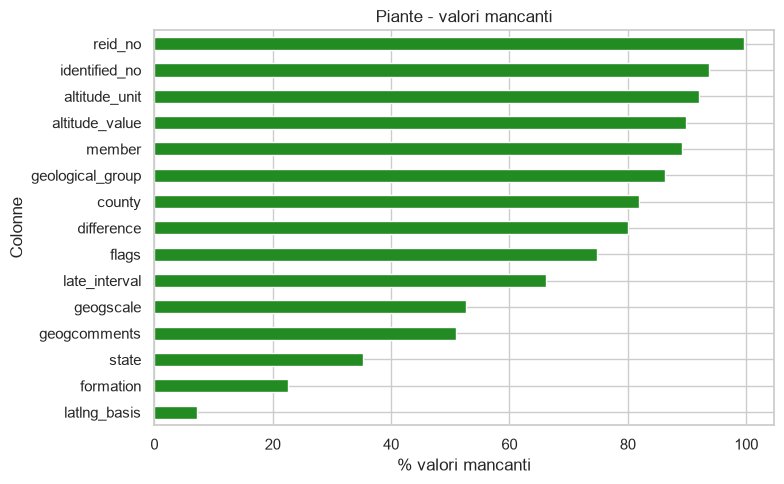

In [36]:
nulli_plants.sort_values().plot(kind='barh', color=verde, figsize=(8, 5))
plt.title('Piante - valori mancanti')
plt.xlabel('% valori mancanti')
plt.ylabel('Colonne')
plt.tight_layout()
plt.show()


### 4.3 Duplicati


#### 4.3.1 Controllo duplicati


In [37]:
df_plants.duplicated().sum()


np.int64(0)

#### 4.3.2 Rimozione duplicati


In [38]:
df_plants_clean = df_plants.drop_duplicates()
print(df_plants.shape)
print(df_plants_clean.shape)


(57394, 38)
(57394, 38)


### 4.4 Conteggi per categoria


#### 4.4.1 Conteggio classi


In [39]:
df_plants['class'].value_counts(dropna=False).head(15)


class
NO_CLASS_SPECIFIED    21096
Polypodiopsida        12665
Ginkgoopsida           4301
Equisetopsida          3355
Cycadopsida            2494
Pteridopsida           2149
Lycopodiopsida         1486
Chlorophyceae          1331
NaN                    1100
Gnetopsida             1016
Pinopsida               846
Dicotyledoneae          764
Magnoliopsida           623
Peltaspermopsida        614
Lyginopteridopsida      444
Name: count, dtype: int64

#### 4.4.2 Conteggio ordini


In [40]:
df_plants['order'].value_counts(dropna=False).head(15)


order
NO_ORDER_SPECIFIED    23150
Coniferales            4011
Bennettitales          3149
Cycadales              2300
Equisetales            1880
NaN                    1847
Ginkgoales             1545
Schizaeales            1314
Czekanowskiales        1243
Cyatheales             1222
Dasycladales           1221
Gleicheniales          1099
Ephedrales             1046
Pinales                 822
Proteales               724
Name: count, dtype: int64

#### 4.4.3 Conteggio famiglie


In [41]:
df_plants['family'].value_counts(dropna=False).head(15)


family
NO_FAMILY_SPECIFIED    29493
Podocarpaceae           2823
NaN                     2210
Araucariaceae           1929
Cyatheaceae             1216
Equisetaceae            1196
Schizaeaceae            1009
Ginkgoaceae              978
Cheirolepidiaceae        974
Gleicheniaceae           721
Osmundaceae              686
Polypodiaceae            675
Dasycladaceae            643
Dipteridaceae            637
Calamitaceae             570
Name: count, dtype: int64

#### 4.4.4 Conteggio generi


In [42]:
df_plants['genus'].value_counts(dropna=False).head(15)


genus
NaN                    2646
Cladophlebis           2364
Coniopteris            1173
Nilsonia               1007
Podozamites             924
Equisetites             878
Ephedripites            838
Classopollis            827
Pterophyllum            808
Cicatricosisporites     769
Cyathidites             717
Czekanowskia            584
Taeniopteris            576
Ginkgo                  567
Pityophyllum            546
Name: count, dtype: int64

#### 4.4.5 Conteggio paesi


In [43]:
df_plants['cc'].value_counts(dropna=False).head(15)


cc
RU    6208
US    6078
CN    5245
AR    4864
BR    3590
IN    2838
EG    2191
CA    2052
AU    1974
AQ    1638
UK    1539
TJ    1151
KZ     880
FR     863
RO     851
Name: count, dtype: int64

#### 4.4.6 Conteggio intervalli geologici


In [44]:
df_plants['early_interval'].value_counts(dropna=False).head(15)


early_interval
Late Jurassic      3395
Maastrichtian      3038
Albian             2846
Carnian            2510
Middle Jurassic    2284
Late Aptian        2238
Early Jurassic     2126
Aptian             1968
Norian             1957
Aalenian           1459
Early Albian       1445
Lancian            1421
Cenomanian         1398
Late Albian        1251
Bajocian           1202
Name: count, dtype: int64

### 4.5 Statistiche descrittive


#### 4.5.1 Statistiche descrittive


In [45]:
df_plants.describe()


,occurrence_no,reid_no,collection_no,identified_no,accepted_no,max_ma,min_ma,reference_no,lng,lat,altitude_value,cx_int_no
count,5.739400e+04,167.000000,57394.000000,3597.000000,57394.000000,57394.000000,57394.000000,57394.000000,57394.000000,57394.000000,5816.000000,57324.000000
mean,7.789207e+05,36764.209581,93396.743858,267378.837364,240363.784281,149.337731,135.531882,31231.252448,12.532439,22.700500,1013.094911,94.246703
std,5.282047e+05,6414.912459,76093.576926,159657.844253,131227.216724,55.096272,53.936862,28058.458710,80.320561,35.479272,1151.551682,104.602506
min,3.128400e+04,10001.000000,1555.000000,53526.000000,24832.000000,72.200000,0.000000,41.000000,-176.000000,-84.000000,-2637.000000,2.000000
25%,3.178562e+05,36545.500000,30236.000000,157259.000000,85569.000000,100.500000,93.900000,8169.000000,-68.006386,2.620556,261.000000,41.000000
50%,3.770765e+05,39595.000000,34796.000000,250494.000000,264632.000000,143.100000,121.400000,8854.000000,21.850000,36.540901,679.000000,112.000000
75%,1.194198e+06,40685.500000,150615.000000,447875.000000,319931.000000,192.900000,174.700000,48166.000000,79.000000,46.398056,1385.000000,119.000000
max,2.064923e+06,42570.000000,278854.000000,515009.000000,517594.000000,298.900000,250.500000,94878.000000,177.083328,81.949997,9050.000000,751.000000


#### 4.5.2 Statistiche colonne numeriche


In [46]:
df_plants[['max_ma', 'min_ma', 'lng', 'lat']].describe()


,max_ma,min_ma,lng,lat
count,57394.000000,57394.000000,57394.000000,57394.000000
mean,149.337731,135.531882,12.532439,22.700500
std,55.096272,53.936862,80.320561,35.479272
min,72.200000,0.000000,-176.000000,-84.000000
25%,100.500000,93.900000,-68.006386,2.620556
50%,143.100000,121.400000,21.850000,36.540901
75%,192.900000,174.700000,79.000000,46.398056
max,298.900000,250.500000,177.083328,81.949997


### 4.6 Visualizzazioni


#### 4.6.1 Grafico classi frequenti


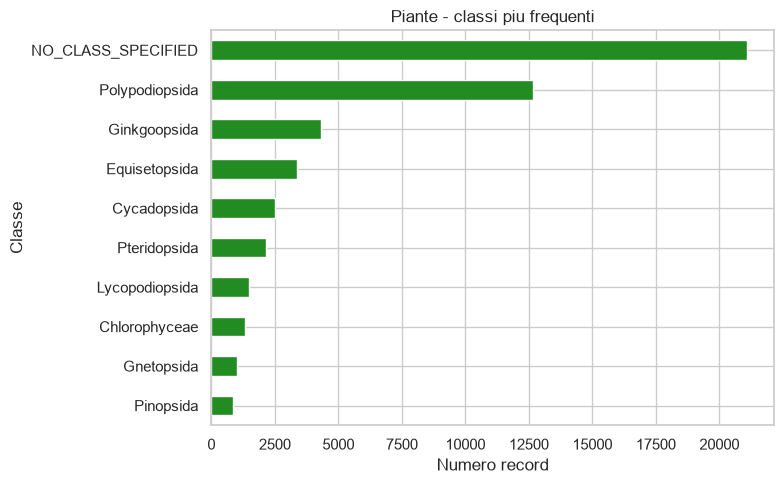

In [47]:
df_plants['class'].value_counts().head(10).sort_values().plot(kind='barh', color=verde, figsize=(8, 5))
plt.title('Piante - classi piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()


#### 4.6.2 Grafico intervalli frequenti


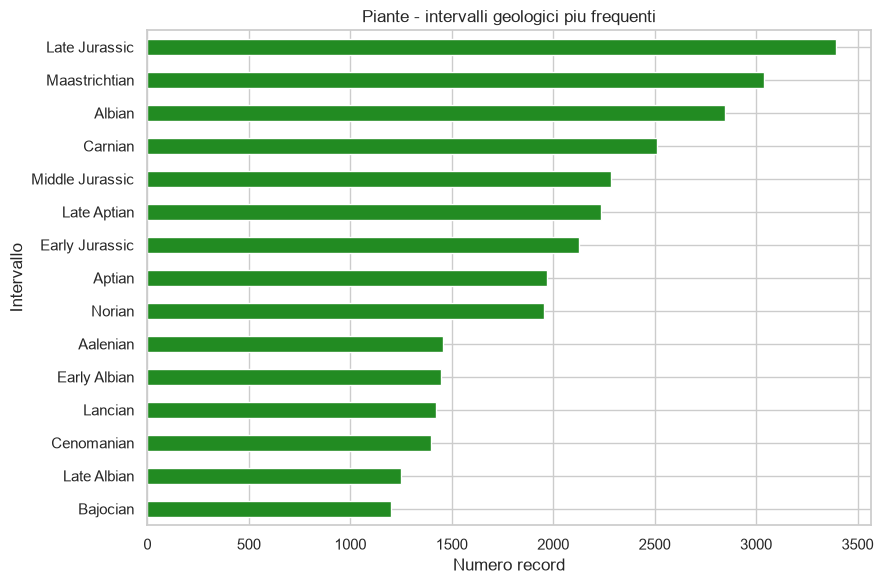

In [48]:
df_plants['early_interval'].value_counts().head(15).sort_values().plot(kind='barh', color=verde, figsize=(9, 6))
plt.title('Piante - intervalli geologici piu frequenti')
plt.xlabel('Numero record')
plt.ylabel('Intervallo')
plt.tight_layout()
plt.show()


#### 4.6.3 Istogramma eta


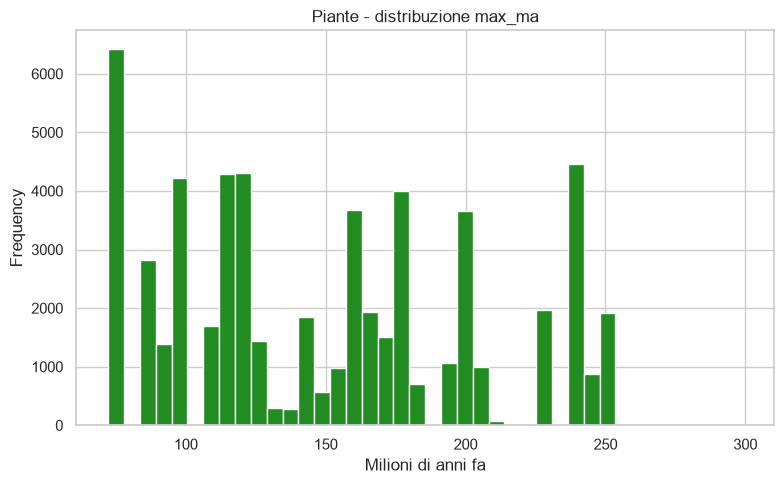

In [49]:
df_plants['max_ma'].dropna().plot(kind='hist', bins=40, color=verde, figsize=(8, 5))
plt.title('Piante - distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.tight_layout()
plt.show()


#### 4.6.4 Boxplot eta


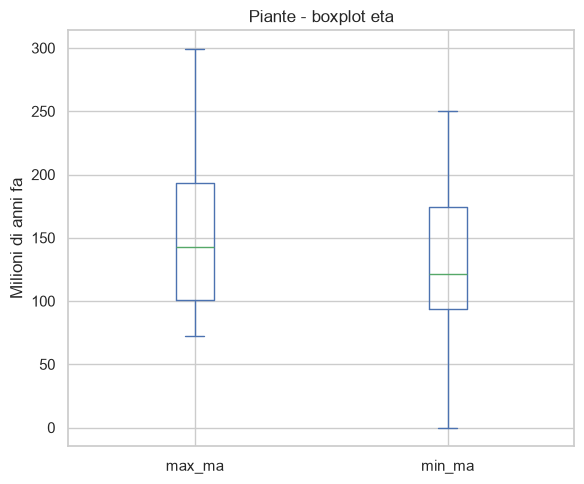

In [50]:
df_plants[['max_ma', 'min_ma']].plot(kind='box', figsize=(6, 5))
plt.title('Piante - boxplot eta')
plt.ylabel('Milioni di anni fa')
plt.tight_layout()
plt.show()


### 4.7 Grafici Seaborn

Stessi grafici dei dinosauri, applicati alle piante.


#### 4.7.1 Grafico seaborn classi


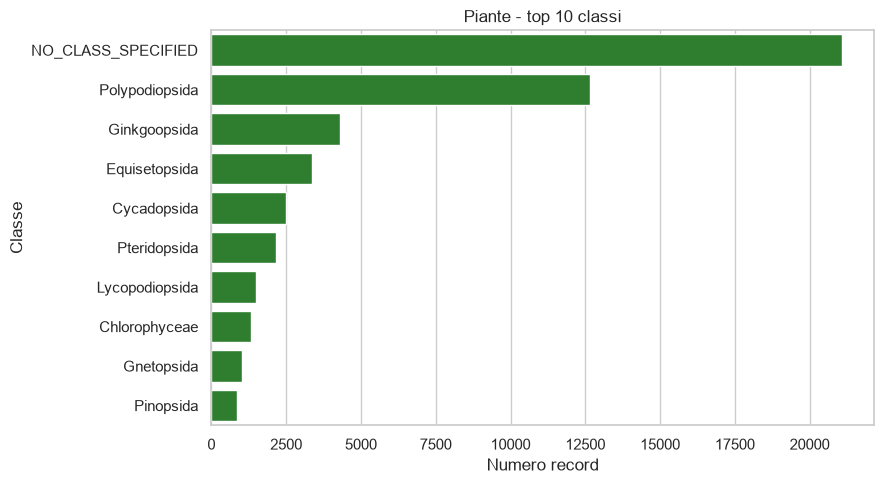

In [51]:
top_classi_plants = df_plants['class'].value_counts().head(10).reset_index()
top_classi_plants.columns = ['class', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_classi_plants, x='conteggio', y='class', color=verde)
plt.title('Piante - top 10 classi')
plt.xlabel('Numero record')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()


#### 4.7.2 Grafico seaborn paesi


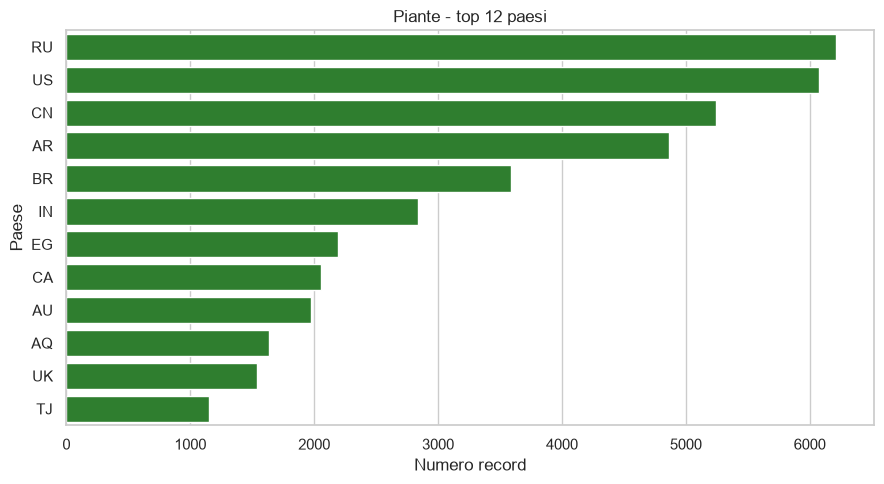

In [52]:
top_paesi_plants = df_plants['cc'].value_counts().head(12).reset_index()
top_paesi_plants.columns = ['cc', 'conteggio']

plt.figure(figsize=(9, 5))
sns.barplot(data=top_paesi_plants, x='conteggio', y='cc', color=verde)
plt.title('Piante - top 12 paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()


#### 4.7.3 Distribuzione temporale seaborn


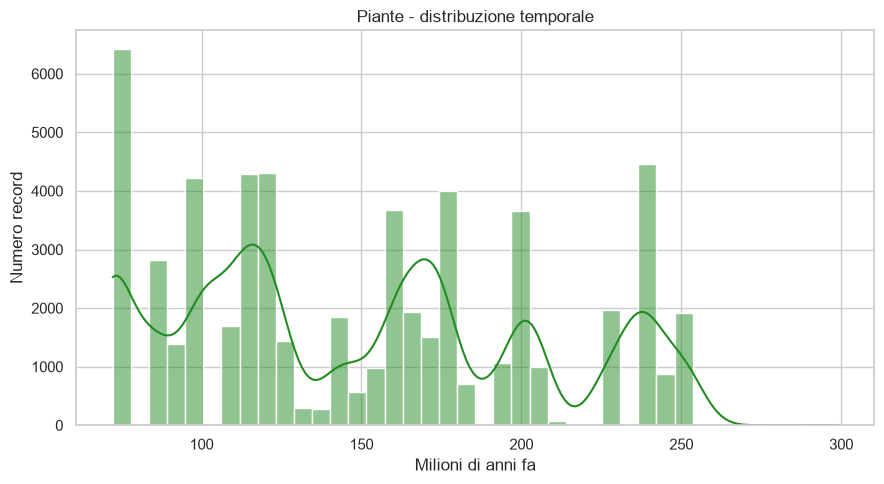

In [53]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df_plants, x='max_ma', bins=40, kde=True, color=verde)
plt.title('Piante - distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.tight_layout()
plt.show()


#### 4.7.4 Boxplot eta per classi


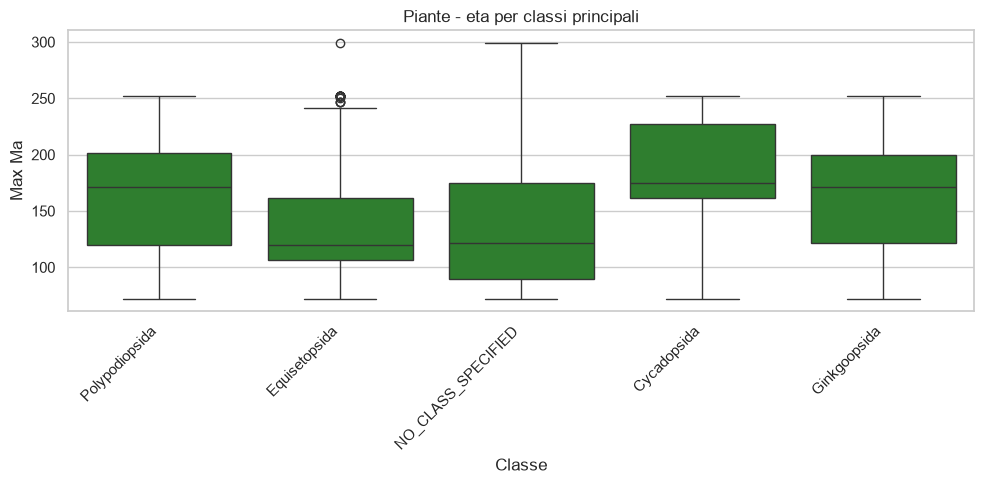

In [54]:
classi_top_plants = df_plants['class'].value_counts().head(5).index
df_plants_classi_top = df_plants[df_plants['class'].isin(classi_top_plants)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_plants_classi_top, x='class', y='max_ma', color=verde)
plt.title('Piante - eta per classi principali')
plt.xlabel('Classe')
plt.ylabel('Max Ma')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


#### 4.7.5 Coordinate geografiche


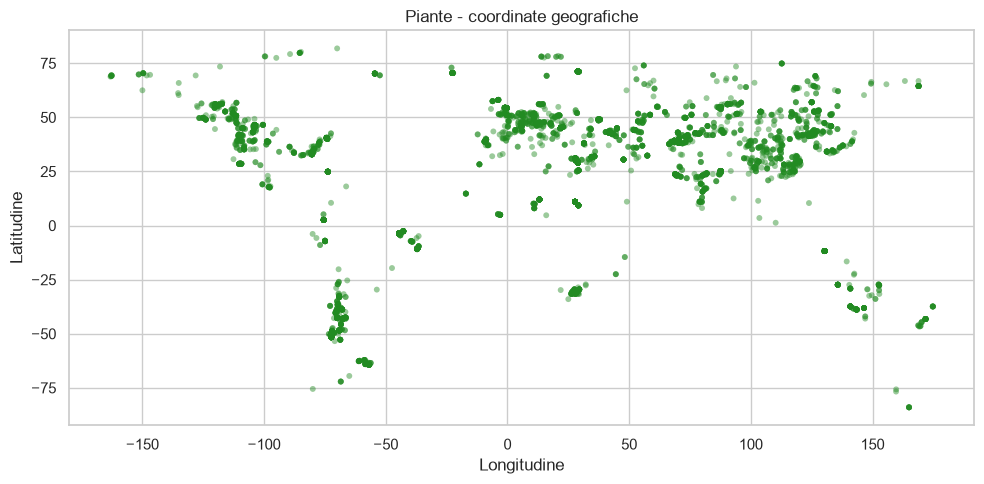

In [55]:
df_plants_geo_sns = df_plants.dropna(subset=['lng', 'lat'])
df_plants_geo_sns = df_plants_geo_sns[df_plants_geo_sns['lat'].between(-90, 90)]
df_plants_geo_sns = df_plants_geo_sns[df_plants_geo_sns['lng'].between(-180, 180)]

if len(df_plants_geo_sns) > 5000:
    df_plants_geo_sns = df_plants_geo_sns.sample(5000, random_state=1)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_plants_geo_sns, x='lng', y='lat', color=verde, alpha=0.45, s=18, edgecolor='none')
plt.title('Piante - coordinate geografiche')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')
plt.tight_layout()
plt.show()


## 5. EDA confronto dinosauri-piante


### 5.1 Confronto base


#### 5.1.1 Tabella confronto generale


In [56]:
confronto = pd.DataFrame({
    'dataset': ['dinosauri', 'piante'],
    'righe': [len(df_dino), len(df_plants)],
    'colonne': [df_dino.shape[1], df_plants.shape[1]],
    'generi': [df_dino['genus'].nunique(), df_plants['genus'].nunique()],
    'famiglie': [df_dino['family'].nunique(), df_plants['family'].nunique()],
    'paesi': [df_dino['cc'].nunique(), df_plants['cc'].nunique()]
})

confronto


,dataset,righe,colonne,generi,famiglie,paesi
0,dinosauri,37790,38,3082,409,168
1,piante,57394,38,1845,248,118


#### 5.1.2 Grafico numero record


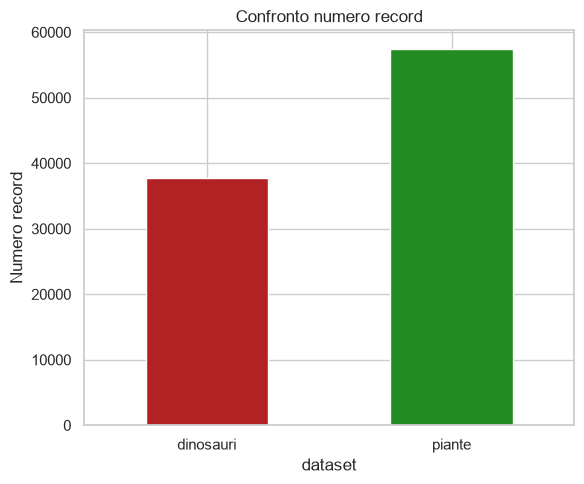

In [57]:
confronto.plot(kind='bar', x='dataset', y='righe', color=[rosso, verde], legend=False, figsize=(6, 5))
plt.title('Confronto numero record')
plt.ylabel('Numero record')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### 5.1.3 Tabella confronto nulli


In [58]:
nulli_confronto = pd.DataFrame({
    'dinosauri': (df_dino.isnull().sum() / len(df_dino) * 100).round(2),
    'piante': (df_plants.isnull().sum() / len(df_plants) * 100).round(2)
})

nulli_confronto.sort_values('dinosauri', ascending=False).head(15)


,dinosauri,piante
flags,90.96,74.73
difference,89.71,79.94
reid_no,89.01,99.71
member,80.93,89.10
altitude_unit,77.30,92.09
altitude_value,77.06,89.87
late_interval,77.04,66.10
geological_group,72.61,86.21
identified_no,66.39,93.73
county,50.44,81.87


#### 5.1.4 Grafico confronto nulli


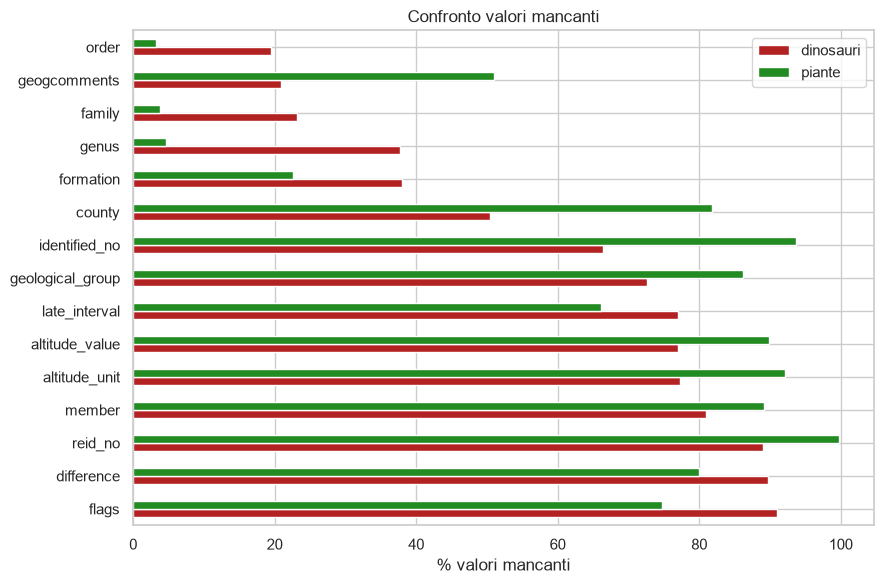

In [59]:
nulli_confronto.sort_values('dinosauri', ascending=False).head(15).plot(kind='barh', color=[rosso, verde], figsize=(9, 6))
plt.title('Confronto valori mancanti')
plt.xlabel('% valori mancanti')
plt.tight_layout()
plt.show()


#### 5.1.5 Confronto distribuzione eta


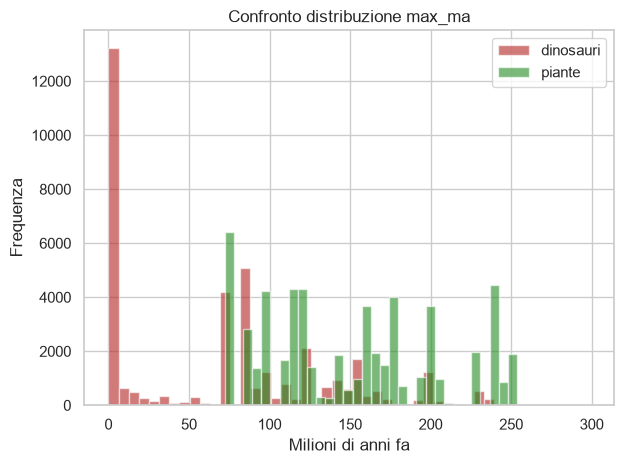

In [60]:
plt.hist(df_dino['max_ma'].dropna(), bins=40, alpha=0.6, color=rosso, label='dinosauri')
plt.hist(df_plants['max_ma'].dropna(), bins=40, alpha=0.6, color=verde, label='piante')
plt.title('Confronto distribuzione max_ma')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Frequenza')
plt.legend()
plt.tight_layout()
plt.show()


#### 5.1.6 Tabella confronto paesi


In [61]:
paesi = pd.DataFrame({
    'dinosauri': df_dino['cc'].value_counts(),
    'piante': df_plants['cc'].value_counts()
}).fillna(0)

paesi['totale'] = paesi['dinosauri'] + paesi['piante']
paesi.sort_values('totale', ascending=False).head(15)


,dinosauri,piante,totale
cc,,,
US,11377.0,6078.0,17455.0
CN,1975.0,5245.0,7220.0
RU,385.0,6208.0,6593.0
AR,1215.0,4864.0,6079.0
CA,2225.0,2052.0,4277.0
BR,582.0,3590.0,4172.0
IN,292.0,2838.0,3130.0
AU,830.0,1974.0,2804.0
UK,1184.0,1539.0,2723.0


#### 5.1.7 Grafico confronto paesi


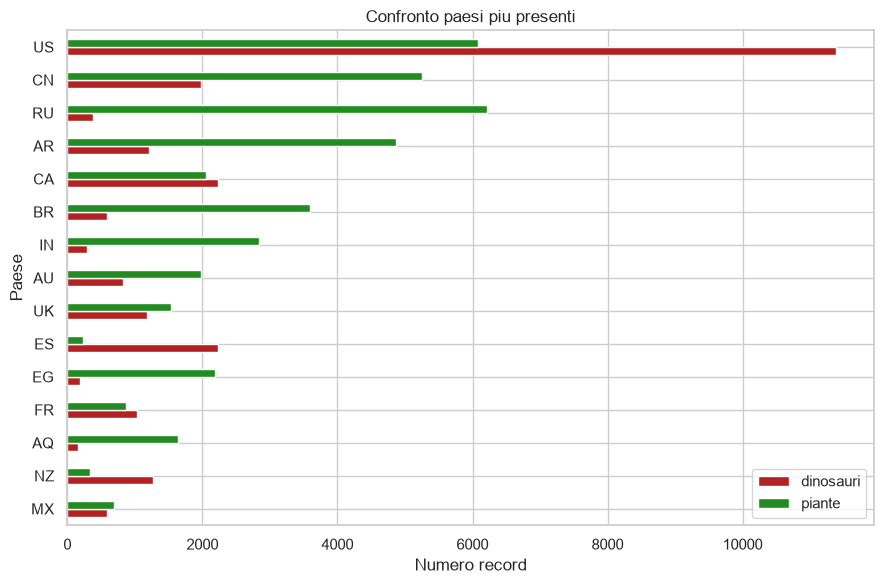

In [62]:
paesi_top15 = paesi.sort_values('totale', ascending=False).head(15)
paesi_top15 = paesi_top15.sort_values('totale')

paesi_top15[['dinosauri', 'piante']].plot(kind='barh', color=[rosso, verde], figsize=(9, 6))
plt.title('Confronto paesi piu presenti')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()


### 5.2 Grafici Seaborn di confronto

Grafici di confronto tra i due dataset, usando sempre rosso per dinosauri e verde per piante.


#### 5.2.1 Grafico metriche principali


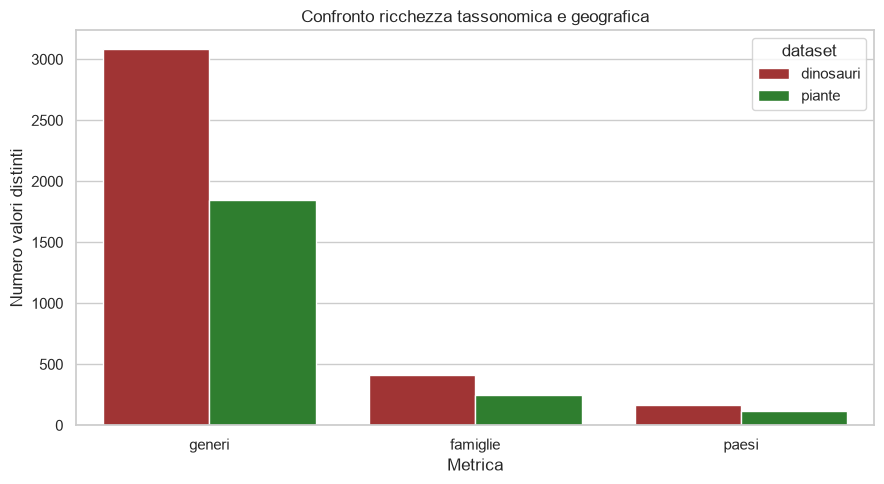

In [63]:
confronto_lungo = confronto.melt(
    id_vars='dataset',
    value_vars=['generi', 'famiglie', 'paesi'],
    var_name='metrica',
    value_name='valore'
)

plt.figure(figsize=(9, 5))
sns.barplot(data=confronto_lungo, x='metrica', y='valore', hue='dataset', palette=[rosso, verde])
plt.title('Confronto ricchezza tassonomica e geografica')
plt.xlabel('Metrica')
plt.ylabel('Numero valori distinti')
plt.tight_layout()
plt.show()


#### 5.2.2 Confronto distribuzione eta seaborn


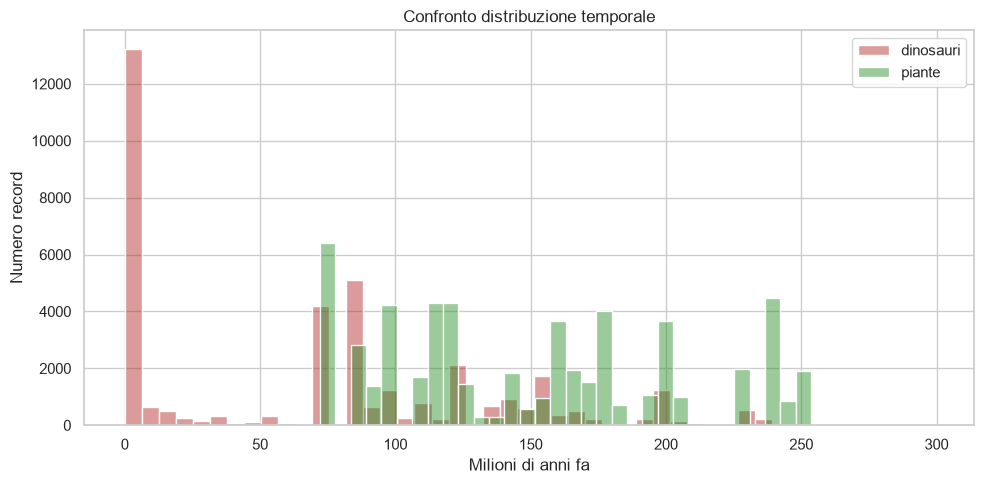

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(df_dino['max_ma'].dropna(), bins=40, color=rosso, alpha=0.45, label='dinosauri')
sns.histplot(df_plants['max_ma'].dropna(), bins=40, color=verde, alpha=0.45, label='piante')
plt.title('Confronto distribuzione temporale')
plt.xlabel('Milioni di anni fa')
plt.ylabel('Numero record')
plt.legend()
plt.tight_layout()
plt.show()


#### 5.2.3 Grafico seaborn paesi


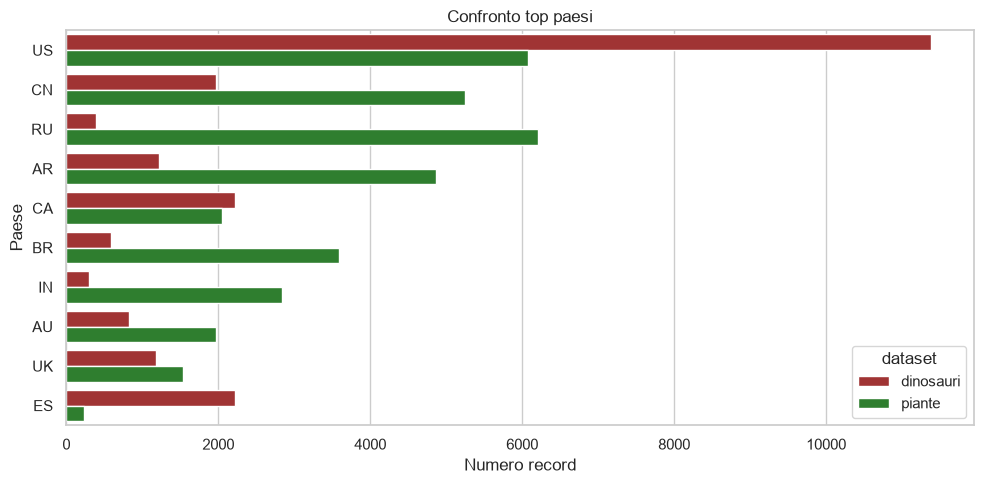

In [65]:
paesi_top = paesi.sort_values('totale', ascending=False).head(10)[['dinosauri', 'piante']].reset_index()
paesi_top = paesi_top.rename(columns={'index': 'cc'})
paesi_top_lungo = paesi_top.melt(id_vars='cc', var_name='dataset', value_name='record')

plt.figure(figsize=(10, 5))
sns.barplot(data=paesi_top_lungo, x='record', y='cc', hue='dataset', palette=[rosso, verde])
plt.title('Confronto top paesi')
plt.xlabel('Numero record')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()


## 6. Feature engineering


Creo poche colonne nuove utili per continuare il progetto, senza fare trasformazioni troppo complesse.


### 6.1 Preparazione dataset unito


#### 6.1.1 Unione dinosauri e piante


In [66]:
df_fossili = pd.concat([df_dino, df_plants], ignore_index=True)

df_fossili['origine_dataset'] = ['dinosauri'] * len(df_dino) + ['piante'] * len(df_plants)

df_fossili.shape


(95184, 39)

#### 6.1.2 Anteprima dataset unito


In [67]:
df_fossili.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus,origine_dataset
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus,dinosauri
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx,dinosauri
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx,dinosauri


#### 6.1.3 Scelta colonne utili


In [68]:
colonne_utili = [
    'occurrence_no', 'collection_no', 'accepted_name', 'accepted_rank',
    'early_interval', 'late_interval', 'max_ma', 'min_ma',
    'lng', 'lat', 'cc', 'state', 'formation', 'geological_group',
    'phylum', 'class', 'order', 'family', 'genus', 'origine_dataset'
]

df_fossili_clean = df_fossili[colonne_utili].copy()
df_fossili_clean.shape


(95184, 20)

#### 6.1.4 Filtro dinosauri non aviani


In [69]:
# Rimuovo Aves dai dinosauri.
df_fossili_clean = df_fossili_clean[~((df_fossili_clean['origine_dataset'] == 'dinosauri') & (df_fossili_clean['class'] == 'Aves'))].copy()
df_fossili_clean.shape


(80011, 20)

#### 6.1.5 Pulizia valori finti nulli


In [70]:
# Sostituisco alcuni valori finti nulli con NaN.
valori_finti_nulli = [
    'NO_ORDER_SPECIFIED',
    'NO_FAMILY_SPECIFIED',
    'NO_GENUS_SPECIFIED',
    'NO_CLASS_SPECIFIED',
    'NO_PHYLUM_SPECIFIED'
]

df_fossili_clean = df_fossili_clean.replace(valori_finti_nulli, np.nan)


#### 6.1.6 Controllo origine dataset


In [71]:
# Controllo del dataset unico dopo le prime modifiche.
df_fossili_clean['origine_dataset'].value_counts()


origine_dataset
piante       57394
dinosauri    22617
Name: count, dtype: int64

#### 6.1.7 Creazione eta media e range


In [72]:
# Eta media e ampiezza dell'intervallo
df_fossili_clean['eta_media_ma'] = (df_fossili_clean['max_ma'] + df_fossili_clean['min_ma']) / 2
df_fossili_clean['range_temporale_ma'] = df_fossili_clean['max_ma'] - df_fossili_clean['min_ma']


#### 6.1.8 Creazione periodo mesozoico


In [73]:
# Periodo geologico semplificato
df_fossili_clean['periodo_mesozoico'] = 'Altro'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 66) & (df_fossili_clean['max_ma'] < 145), 'periodo_mesozoico'] = 'Cretaceo'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 145) & (df_fossili_clean['max_ma'] < 201.3), 'periodo_mesozoico'] = 'Giurassico'
df_fossili_clean.loc[(df_fossili_clean['max_ma'] >= 201.3) & (df_fossili_clean['max_ma'] <= 252), 'periodo_mesozoico'] = 'Triassico' 


#### 6.1.9 Coordinate presenti


In [74]:
# Coordinate presenti
df_fossili_clean['coordinate_presenti'] = df_fossili_clean['lat'].notnull() & df_fossili_clean['lng'].notnull()


#### 6.1.10 Completezza tassonomica


In [75]:
# Completezza tassonomica: conto quanti campi tassonomici sono valorizzati
df_fossili_clean['completezza_tassonomica'] = df_fossili_clean[['phylum', 'class', 'order', 'family', 'genus']].notnull().sum(axis=1)


### 6.2 Feature aggiuntive

Aggiungo qualche feature in piu, utile per analisi successive ma ancora semplice da leggere.


#### 6.2.1 Coordinate valide


In [76]:
# Coordinate valide: controllo anche che latitudine e longitudine siano in range possibile.
df_fossili_clean['coordinate_valide'] = (
    df_fossili_clean['lat'].between(-90, 90)
    & df_fossili_clean['lng'].between(-180, 180)
    & df_fossili_clean['coordinate_presenti']
)


#### 6.2.2 Creazione emisfero


In [77]:
# Emisfero in base alla latitudine.
df_fossili_clean['emisfero'] = 'Sconosciuto'
df_fossili_clean.loc[df_fossili_clean['lat'] >= 0, 'emisfero'] = 'Nord'
df_fossili_clean.loc[df_fossili_clean['lat'] < 0, 'emisfero'] = 'Sud'


#### 6.2.3 Creazione fascia latitudine


In [78]:
# Fascia latitudine semplice.
df_fossili_clean['fascia_latitudine'] = 'Sconosciuta'
df_fossili_clean.loc[df_fossili_clean['lat'].between(-23.5, 23.5), 'fascia_latitudine'] = 'Tropicale'
df_fossili_clean.loc[df_fossili_clean['lat'].between(23.5, 66.5), 'fascia_latitudine'] = 'Temperata Nord'
df_fossili_clean.loc[df_fossili_clean['lat'].between(-66.5, -23.5), 'fascia_latitudine'] = 'Temperata Sud'
df_fossili_clean.loc[df_fossili_clean['lat'] > 66.5, 'fascia_latitudine'] = 'Polare Nord'
df_fossili_clean.loc[df_fossili_clean['lat'] < -66.5, 'fascia_latitudine'] = 'Polare Sud'


#### 6.2.4 Taxonomia completa


In [79]:
# Flag sulla tassonomia completa.
df_fossili_clean['taxonomia_completa'] = df_fossili_clean['completezza_tassonomica'] == 5


#### 6.2.5 Precisione temporale


In [80]:
# Lunghezza del range temporale divisa in classi semplici.
df_fossili_clean['precisione_temporale'] = 'Ampia'
df_fossili_clean.loc[df_fossili_clean['range_temporale_ma'] <= 5, 'precisione_temporale'] = 'Alta'
df_fossili_clean.loc[(df_fossili_clean['range_temporale_ma'] > 5) & (df_fossili_clean['range_temporale_ma'] <= 20), 'precisione_temporale'] = 'Media'


#### 6.2.6 Anteprima nuove feature


In [81]:
df_fossili_clean[[
    'origine_dataset', 'periodo_mesozoico', 'eta_media_ma', 'range_temporale_ma',
    'coordinate_presenti', 'coordinate_valide', 'emisfero', 'fascia_latitudine',
    'completezza_tassonomica', 'taxonomia_completa', 'precisione_temporale'
]].head()


,origine_dataset,periodo_mesozoico,eta_media_ma,range_temporale_ma,coordinate_presenti,coordinate_valide,emisfero,fascia_latitudine,completezza_tassonomica,taxonomia_completa,precisione_temporale
2,dinosauri,Giurassico,142.405,19.61,True,True,Nord,Temperata Nord,4,False,Media
3,dinosauri,Cretaceo,122.670,6.20,True,True,Nord,Temperata Nord,3,False,Media
4,dinosauri,Cretaceo,122.670,6.20,True,True,Nord,Temperata Nord,3,False,Media
5,dinosauri,Cretaceo,77.900,11.40,True,True,Nord,Temperata Nord,2,False,Media
6,dinosauri,Cretaceo,128.150,29.90,True,True,Nord,Temperata Nord,2,False,Ampia


#### 6.2.7 Riepilogo feature per dataset


In [82]:
df_fossili_clean.groupby('origine_dataset')[[
    'coordinate_presenti', 'coordinate_valide', 'taxonomia_completa', 'completezza_tassonomica'
]].mean().round(2)


,coordinate_presenti,coordinate_valide,taxonomia_completa,completezza_tassonomica
origine_dataset,,,,
dinosauri,1.0,1.0,0.04,3.06
piante,1.0,1.0,0.21,3.52


#### 6.2.8 Conteggio precisione temporale


In [83]:
df_fossili_clean['precisione_temporale'].value_counts()


precisione_temporale
Media    54566
Ampia    12832
Alta     12613
Name: count, dtype: int64

#### 6.2.9 Grafico completezza tassonomica


C:\Users\lorenzo.capelletti\AppData\Local\Temp\11\ipykernel_10376\2297133842.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fossili_clean, x='origine_dataset', y='completezza_tassonomica', palette=[rosso, verde])


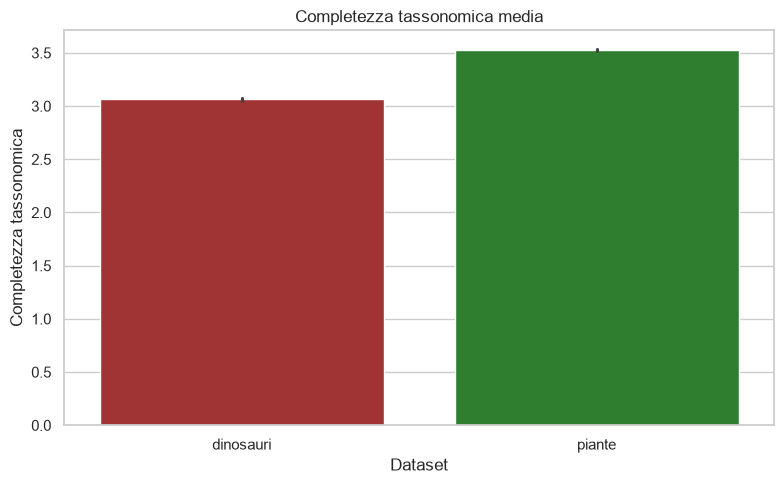

In [84]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_fossili_clean, x='origine_dataset', y='completezza_tassonomica', palette=[rosso, verde])
plt.title('Completezza tassonomica media')
plt.xlabel('Dataset')
plt.ylabel('Completezza tassonomica')
plt.tight_layout()
plt.show()


#### 6.2.10 Grafico periodi mesozoici


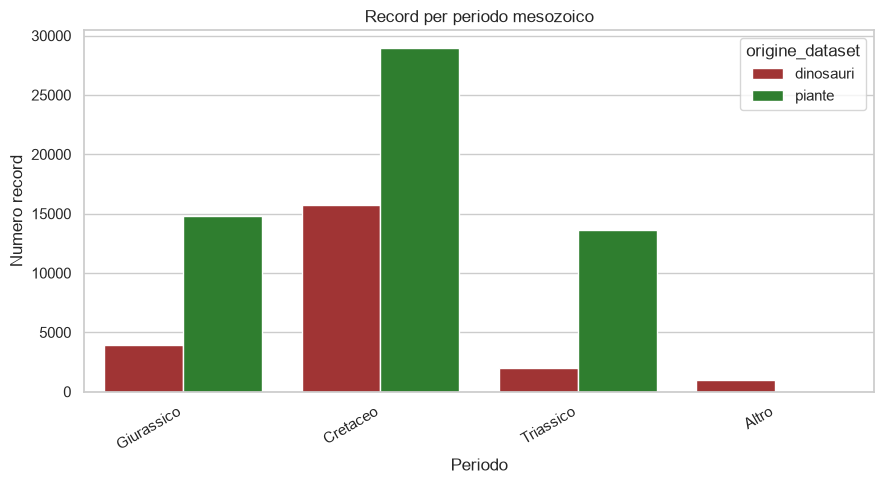

In [85]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_fossili_clean, x='periodo_mesozoico', hue='origine_dataset', palette=[rosso, verde])
plt.title('Record per periodo mesozoico')
plt.xlabel('Periodo')
plt.ylabel('Numero record')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### 6.2.11 Anteprima dataset unito


In [86]:
df_fossili.head()


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,...,cx_int_no,formation,geological_group,member,phylum,class,order,family,genus,origine_dataset
0,41524,occ,NaN,NaN,3257,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
1,41580,occ,NaN,NaN,3256,Aves indet.,class,NaN,NaN,Aves,...,37.0,NaN,Bracklesham,NaN,Chordata,Aves,NaN,NaN,NaN,dinosauri
2,130209,occ,NaN,NaN,10755,Chaoyangosaurus liaosiensis n. gen. n. sp.,species,65704.0,NaN,Chaoyangsaurus youngi,...,2.0,Tuchengzi,NaN,NaN,Chordata,Ornithischia,NO_ORDER_SPECIFIED,Chaoyangsauridae,Chaoyangsaurus,dinosauri
3,130294,occ,NaN,NaN,10764,Protarchaeopteryx robusta n. gen. n. sp.,species,NaN,NaN,Protarchaeopteryx robusta,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Protarchaeopteryx,dinosauri
4,130295,occ,NaN,NaN,10764,Caudipteryx zoui n. gen. n. sp.,species,NaN,NaN,Caudipteryx zoui,...,40.0,Yixian,Jehol,Jianshangou,Chordata,Reptilia,NO_ORDER_SPECIFIED,NO_FAMILY_SPECIFIED,Caudipteryx,dinosauri


#### 6.2.12 Statistiche feature create


In [87]:
df_fossili_clean[['eta_media_ma', 'range_temporale_ma', 'completezza_tassonomica']].describe()


,eta_media_ma,range_temporale_ma,completezza_tassonomica
count,80011.00000,80011.000000,80011.000000
mean,132.88673,12.709404,3.393771
std,54.80735,11.633168,1.116744
min,0.00585,0.011700,0.000000
25%,84.65000,6.200000,3.000000
50%,119.48500,9.470000,4.000000
75%,170.00000,17.330000,4.000000
max,251.20100,167.280000,5.000000


#### 6.2.13 Conteggio periodi mesozoici


In [88]:
df_fossili_clean['periodo_mesozoico'].value_counts()


periodo_mesozoico
Cretaceo      44740
Giurassico    18664
Triassico     15650
Altro           957
Name: count, dtype: int64

#### 6.2.14 Media feature per dataset


In [89]:
df_fossili_clean.groupby('origine_dataset')[['coordinate_presenti', 'completezza_tassonomica']].mean().round(2)


,coordinate_presenti,completezza_tassonomica
origine_dataset,,
dinosauri,1.0,3.06
piante,1.0,3.52


## 7. Studio riempimento tassonomia

Qui provo a riempire un po' meglio `phylum`, `class`, `order`, `family` e `genus`.

Uso prima il dataset principale e poi alcuni CSV gia presenti nella cartella. L'idea resta semplice: creo delle mappe e uso `fillna()` per riempire solo i valori mancanti.


### 7.1 Controllo dei nulli tassonomici


#### 7.1.1 Nulli iniziali


In [90]:
colonne_tassonomia = ['phylum', 'class', 'order', 'family', 'genus']

nulli_tassonomia_prima = df_fossili_clean[colonne_tassonomia].isnull().sum()
nulli_tassonomia_prima


phylum     3145
class     22196
order     46310
family    42147
genus     14718
dtype: int64

#### 7.1.2 Percentuale nulli iniziali


In [91]:
(df_fossili_clean[colonne_tassonomia].isnull().sum() / len(df_fossili_clean) * 100).round(2)


phylum     3.93
class     27.74
order     57.88
family    52.68
genus     18.39
dtype: float64

### 7.2 Dataset di supporto

Carico alcuni file della cartella che possono aiutare a recuperare informazioni tassonomiche.


#### 7.2.1 Caricamento file di supporto


In [ ]:
import os

# Uso il dataset pulito gia creato nel notebook: il CSV salvato risulta corrotto.
df_pulito = df_fossili_clean.copy()
df_lookup = pd.read_csv('lookup_tassonomia_dinosauri_extra.csv')

mapping_path = 'report_mapping_tassonomici.csv'
if os.path.exists(mapping_path):
    df_mapping = pd.read_csv(mapping_path)
else:
    df_mapping = pd.DataFrame(columns=['passaggio', 'chiave', 'valore_scelto', 'affidabile'])
    print('report_mapping_tassonomici.csv non trovato: salto questa fonte opzionale.')

df_mapping['affidabile'] = df_mapping['affidabile'].fillna(False).astype(bool)

df_dino_extra = pd.read_csv('dinosaurs.csv')

print('dataset pulito in memoria:', df_pulito.shape)
print('lookup_tassonomia_dinosauri_extra:', df_lookup.shape)
print('report_mapping_tassonomici:', df_mapping.shape)
print('dinosaurs:', df_dino_extra.shape)


#### 7.2.2 Preparazione colonne utili


In [ ]:
df_pulito_tax = df_pulito.rename(columns={
    'id': 'occurrence_no',
    'nome': 'accepted_name',
    'rango': 'accepted_rank',
    'classe': 'class',
    'ordine': 'order',
    'famiglia': 'family',
    'genere': 'genus'
})
df_pulito_tax = df_pulito_tax[['occurrence_no', 'phylum', 'class', 'order', 'family', 'genus']]

df_lookup_tax = df_lookup.rename(columns={
    'genere': 'genus',
    'classe': 'class',
    'ordine': 'order',
    'famiglia': 'family'
})
df_lookup_tax = df_lookup_tax[['genus', 'phylum', 'class', 'order', 'family']]

df_dino_extra_tax = df_dino_extra.rename(columns={'name': 'genus'})
df_dino_extra_tax = df_dino_extra_tax[['genus', 'class', 'family']]

df_mapping_ok = df_mapping[df_mapping['affidabile'] == True].copy()
df_mapping_ok.head()


#### 7.2.3 Fonti usate


In [ ]:
fonti_tassonomia = pd.DataFrame({
    'file': [
        'dataset_fossili_pulito.csv',
        'lookup_tassonomia_dinosauri_extra.csv',
        'report_mapping_tassonomici.csv',
        'dinosaurs.csv'
    ],
    'uso': [
        'riempimento diretto tramite occurrence_no',
        'riempimento tramite genere',
        'mapping affidabili tramite genere',
        'classe e famiglia dei dinosauri'
    ]
})

fonti_tassonomia


### 7.3 Riempimento del genere

Prima provo a recuperare `genus` dalla prima parola di `accepted_name`, solo quando il rango e' adatto.


#### 7.3.1 Genere da accepted_name


In [ ]:
genus_prima = df_fossili_clean['genus'].isnull().sum()

maschera_genere = (
    df_fossili_clean['genus'].isnull()
    & df_fossili_clean['accepted_name'].notnull()
    & df_fossili_clean['accepted_rank'].isin(['genus', 'species', 'subspecies'])
)

df_fossili_clean.loc[maschera_genere, 'genus'] = df_fossili_clean.loc[maschera_genere, 'accepted_name'].str.split().str[0]

genus_dopo = df_fossili_clean['genus'].isnull().sum()
print('genus riempiti:', genus_prima - genus_dopo)


### 7.4 Riempimento con altri dataset

Qui uso i file di supporto. Prima riempio con `occurrence_no`, poi con il nome del genere.


#### 7.4.1 Riempimento diretto da dataset pulito


In [ ]:
for col in colonne_tassonomia:
    mappa = df_pulito_tax.dropna(subset=['occurrence_no', col]).drop_duplicates('occurrence_no').set_index('occurrence_no')[col]
    df_fossili_clean[col] = df_fossili_clean[col].fillna(df_fossili_clean['occurrence_no'].map(mappa))

df_fossili_clean[colonne_tassonomia].isnull().sum()


#### 7.4.2 Chiave del genere


In [ ]:
df_fossili_clean['genere_key'] = df_fossili_clean['genus'].str.lower()
df_pulito_tax['genere_key'] = df_pulito_tax['genus'].str.lower()
df_lookup_tax['genere_key'] = df_lookup_tax['genus'].str.lower()
df_dino_extra_tax['genere_key'] = df_dino_extra_tax['genus'].str.lower()


#### 7.4.3 Riempimento dai mapping affidabili


In [ ]:
mappa_famiglia = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> famiglia'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_ordine = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> ordine'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_classe = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> classe'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']
mappa_phylum = df_mapping_ok[df_mapping_ok['passaggio'] == 'genere -> phylum'].drop_duplicates('chiave').set_index('chiave')['valore_scelto']

df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia))
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['genere_key'].map(mappa_ordine))
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['genere_key'].map(mappa_classe))
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['genere_key'].map(mappa_phylum))

df_fossili_clean[colonne_tassonomia].isnull().sum()


#### 7.4.4 Riempimento da lookup e dinosaurs


In [ ]:
df_supporto_genere = pd.concat([
    df_lookup_tax[['genere_key', 'phylum', 'class', 'order', 'family']],
    df_dino_extra_tax[['genere_key', 'class', 'family']]
], ignore_index=True)

mappa_famiglia_extra = df_supporto_genere.dropna(subset=['genere_key', 'family']).drop_duplicates('genere_key').set_index('genere_key')['family']
mappa_ordine_extra = df_supporto_genere.dropna(subset=['genere_key', 'order']).drop_duplicates('genere_key').set_index('genere_key')['order']
mappa_classe_extra = df_supporto_genere.dropna(subset=['genere_key', 'class']).drop_duplicates('genere_key').set_index('genere_key')['class']
mappa_phylum_extra = df_supporto_genere.dropna(subset=['genere_key', 'phylum']).drop_duplicates('genere_key').set_index('genere_key')['phylum']

df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia_extra))
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['genere_key'].map(mappa_ordine_extra))
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['genere_key'].map(mappa_classe_extra))
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['genere_key'].map(mappa_phylum_extra))

df_fossili_clean[colonne_tassonomia].isnull().sum()


#### 7.4.5 Riempimento interno al dataset


In [ ]:
mappa_famiglia = df_fossili_clean.groupby('genere_key')['family'].first()
df_fossili_clean['family'] = df_fossili_clean['family'].fillna(df_fossili_clean['genere_key'].map(mappa_famiglia))

mappa_ordine = df_fossili_clean.groupby('family')['order'].first()
df_fossili_clean['order'] = df_fossili_clean['order'].fillna(df_fossili_clean['family'].map(mappa_ordine))

mappa_classe = df_fossili_clean.groupby('order')['class'].first()
df_fossili_clean['class'] = df_fossili_clean['class'].fillna(df_fossili_clean['order'].map(mappa_classe))

mappa_phylum = df_fossili_clean.groupby('class')['phylum'].first()
df_fossili_clean['phylum'] = df_fossili_clean['phylum'].fillna(df_fossili_clean['class'].map(mappa_phylum))

df_fossili_clean[colonne_tassonomia].isnull().sum()


### 7.5 Confronto prima e dopo il riempimento


#### 7.5.1 Tabella confronto nulli


In [ ]:
nulli_tassonomia_dopo = df_fossili_clean[colonne_tassonomia].isnull().sum()

confronto_nulli_tassonomia = pd.DataFrame({
    'prima': nulli_tassonomia_prima,
    'dopo': nulli_tassonomia_dopo
})
confronto_nulli_tassonomia['riempiti'] = confronto_nulli_tassonomia['prima'] - confronto_nulli_tassonomia['dopo']

confronto_nulli_tassonomia


#### 7.5.2 Grafico confronto nulli


In [ ]:
confronto_nulli_tassonomia[['prima', 'dopo']].sort_values('prima').plot(kind='barh', color=['lightgray', verde], figsize=(8, 5))
plt.title('Nulli tassonomici prima e dopo')
plt.xlabel('Numero valori nulli')
plt.ylabel('Colonna')
plt.tight_layout()
plt.show()


#### 7.5.3 Record ancora incompleti


In [ ]:
df_fossili_clean[df_fossili_clean[colonne_tassonomia].isnull().any(axis=1)][[
    'accepted_name', 'accepted_rank', 'phylum', 'class', 'order', 'family', 'genus'
]].head(10)


### 7.6 Nota sul metodo

Questo metodo non e' perfetto, pero' e' facile da controllare: prima uso gli ID quando esistono, poi il genere, poi le relazioni gia presenti nel dataset.

I valori riempiti dai CSV di supporto vanno comunque controllati se vengono usati per analisi finali molto precise.


## 8. Conclusioni


### Cose viste

- I due dataset hanno la stessa struttura.
- Il dataset unito si chiama `df_fossili`.
- Il dataset pulito e arricchito si chiama `df_fossili_clean`.
- Ci sono valori mancanti, soprattutto in colonne geografiche e stratigrafiche.
- I duplicati non sembrano essere il problema principale.
- Nel dataset dinosauri conviene togliere `Aves` se si vogliono analizzare solo dinosauri non-aviani.
- Alcuni valori tassonomici tipo `NO_..._SPECIFIED` vanno considerati come nulli.
- Per riempire la tassonomia uso anche alcuni CSV di supporto presenti nella cartella.
- Le feature create possono aiutare nella parte successiva del progetto.


### Prossimi passi

- Decidere quali colonne tenere.
- Gestire i valori mancanti con `dropna()` o `fillna()` in base al caso.
- Usare `df_fossili_clean` per continuare con ETL, data warehouse o dashboard.
- Scegliere i grafici piu utili per il report finale.
